
### Import libraries

In [42]:
import sys
import os
from pathlib import Path
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt


In [43]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

#### import functions

In [44]:
project_root = Path().resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [45]:
from helper_functions.simulation import generate_toy_logistic_data
from helper_functions.styling import set_latex_plot_style, save_latex_figure

In [46]:
set_latex_plot_style()

### Code

In [47]:
def add_symmetric_label_noise(y, noise_level=0.1, seed=None):
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    flip_mask = rng.uniform(0.0, 1.0, size=len(y)) < noise_level
    y_noisy[flip_mask] = 1 - y_noisy[flip_mask]
    return y_noisy, flip_mask


In [48]:
data = load_breast_cancer()
X = data.data
y_true = data.target

X_train, X_test, y_train_true, y_test_true = train_test_split(
    X, y_true, test_size=0.3, random_state=0, stratify=y_true
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Train prevalence:", y_train_true.mean(), "Test prevalence:", y_test_true.mean())


X_train: (398, 30) X_test: (171, 30)
Train prevalence: 0.628140703517588 Test prevalence: 0.6257309941520468


In [49]:
clf_clean = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        l1_ratio=0,
        C = 1e6,
        solver="lbfgs",
        max_iter = 5000,
    ))
])

clf_clean.fit(X_train, y_train_true)

p_test_clean = clf_clean.predict_proba(X_test)[:,1]
yhat_test_clean = clf_clean.predict(X_test)

print("CLEAN TRAINING LABELS")
print("Accuracy:", accuracy_score(y_test_true, yhat_test_clean))
print("AUC:", roc_auc_score(y_test_true, p_test_clean))
print("Log loss:", log_loss(y_test_true, p_test_clean))

CLEAN TRAINING LABELS
Accuracy: 0.9532163742690059
AUC: 0.9811623831775701
Log loss: 1.487076928280641


In [50]:
y_train_noisy, flip_mask = add_symmetric_label_noise(y_train_true, noise_level=0.1, seed=6114)


In [51]:
clf_noisy = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        l1_ratio=0,
        C=1e6,
        solver="lbfgs",
        max_iter=5000
    ))
])

clf_noisy.fit(X_train, y_train_noisy)

p_test_noisy = clf_noisy.predict_proba(X_test)[:, 1]
yhat_test_noisy = clf_noisy.predict(X_test)

print("NOISY TRAINING LABELS")
print("Accuracy:", accuracy_score(y_test_true, yhat_test_noisy))
print("AUC:", roc_auc_score(y_test_true, p_test_noisy))
print("Log loss:", log_loss(y_test_true, p_test_noisy))


NOISY TRAINING LABELS
Accuracy: 0.9298245614035088
AUC: 0.9799941588785046
Log loss: 0.22561885515027488


In [52]:
coef_clean = clf_clean.named_steps["logreg"].coef_.ravel()
coef_noisy = clf_noisy.named_steps["logreg"].coef_.ravel()

# How much they changed
diff = coef_noisy - coef_clean

print("Mean |coef_clean|:", np.mean(np.abs(coef_clean)))
print("Mean |coef_noisy|:", np.mean(np.abs(coef_noisy)))
print("Mean |diff|:", np.mean(np.abs(diff)))
print("Max |diff|:", np.max(np.abs(diff)))


Mean |coef_clean|: 56.59326976786113
Mean |coef_noisy|: 1.0895780329136378
Mean |diff|: 56.28965013967761
Max |diff|: 193.275209115872


['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


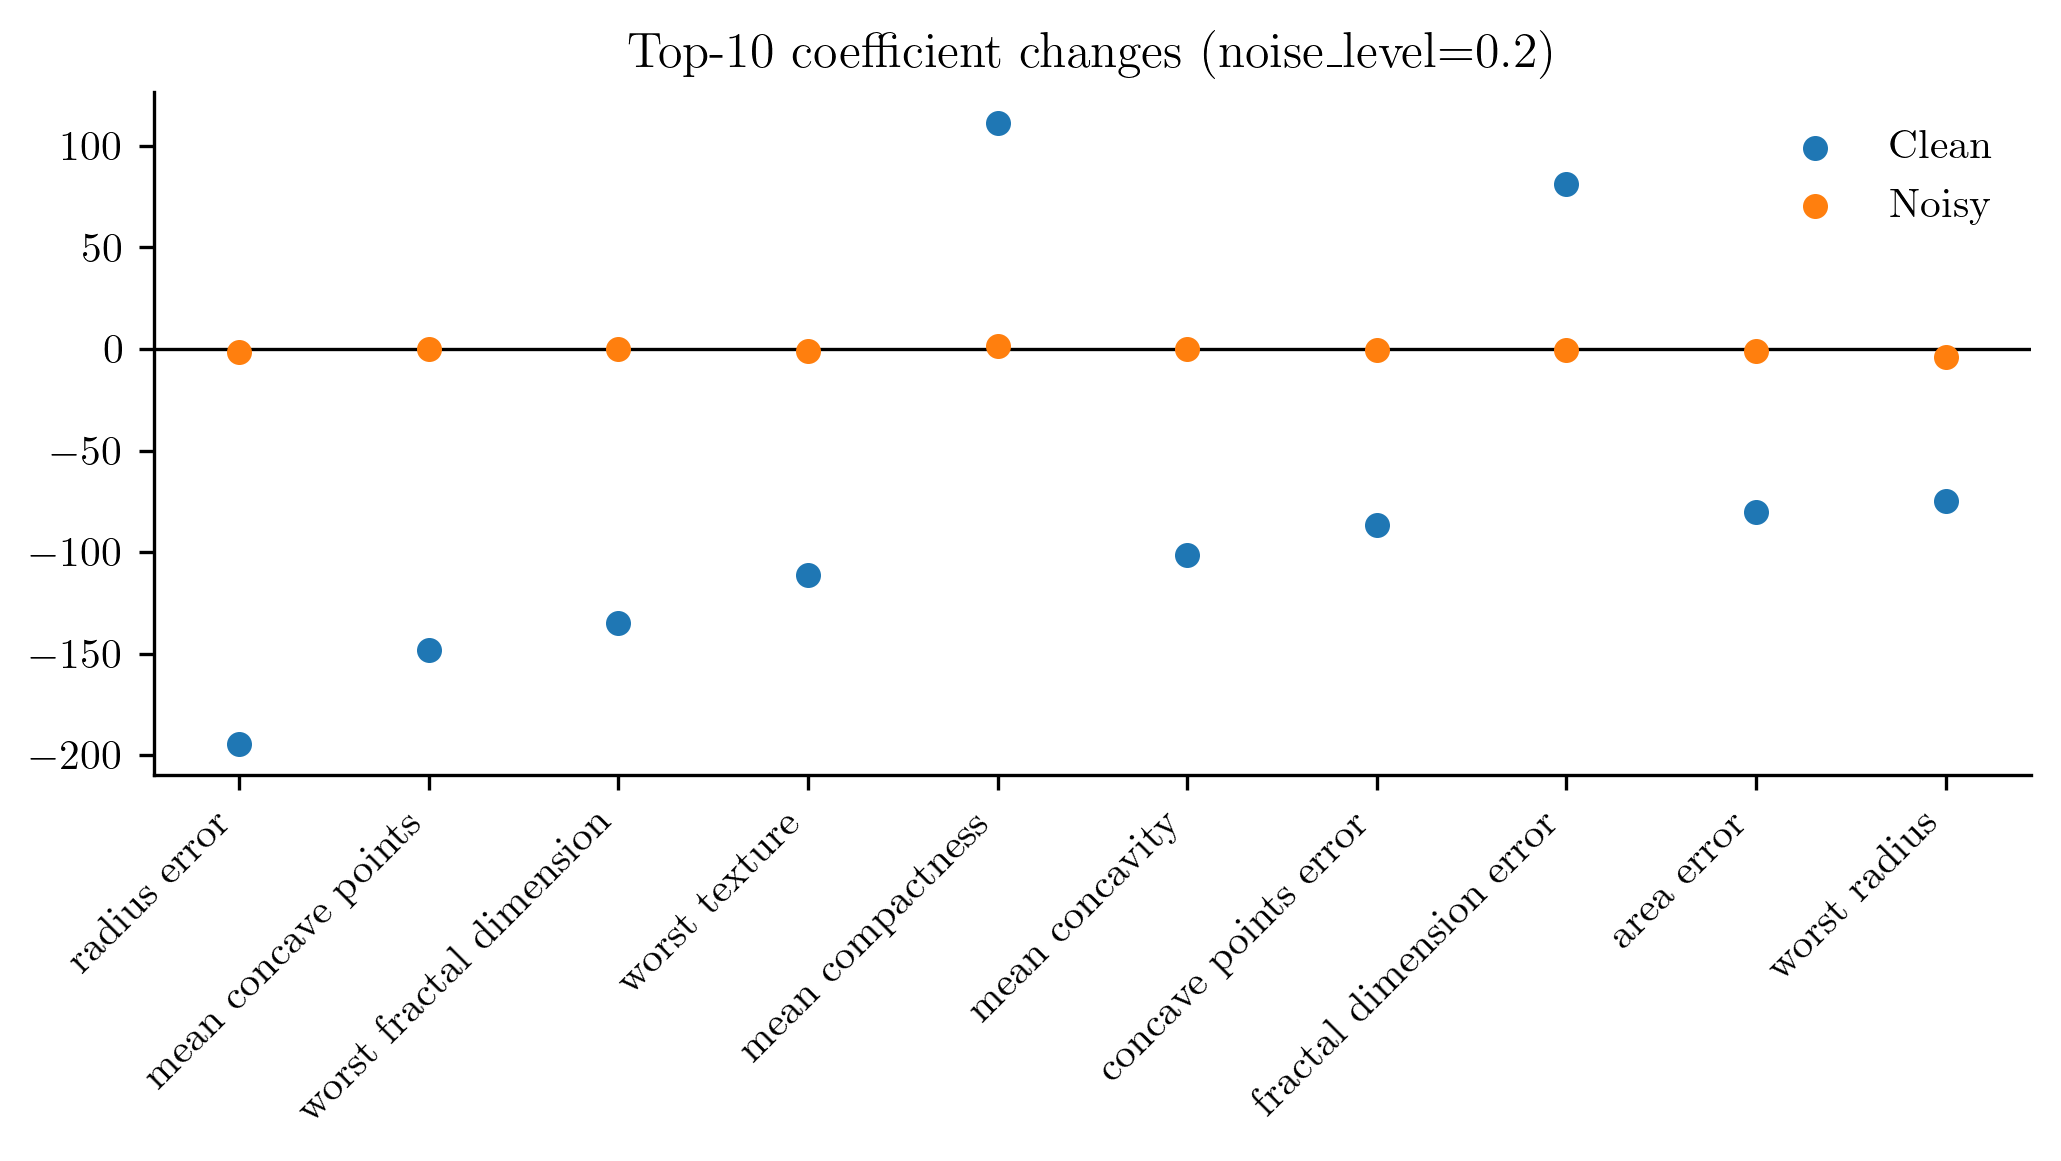

In [53]:
import matplotlib.pyplot as plt

feature_names = data.feature_names
print(feature_names)
k = 10
top_idx = np.argsort(np.abs(diff))[-k:][::-1]

plt.figure(figsize=(7, 4))
x = np.arange(k)

plt.scatter(x, coef_clean[top_idx], label="Clean", zorder=3)
plt.scatter(x, coef_noisy[top_idx], label="Noisy", zorder=3)

plt.xticks(x, feature_names[top_idx], rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=0.8)
plt.title(f"Top-{k} coefficient changes (noise_level={0.2})")
plt.legend()
plt.tight_layout()
plt.show()


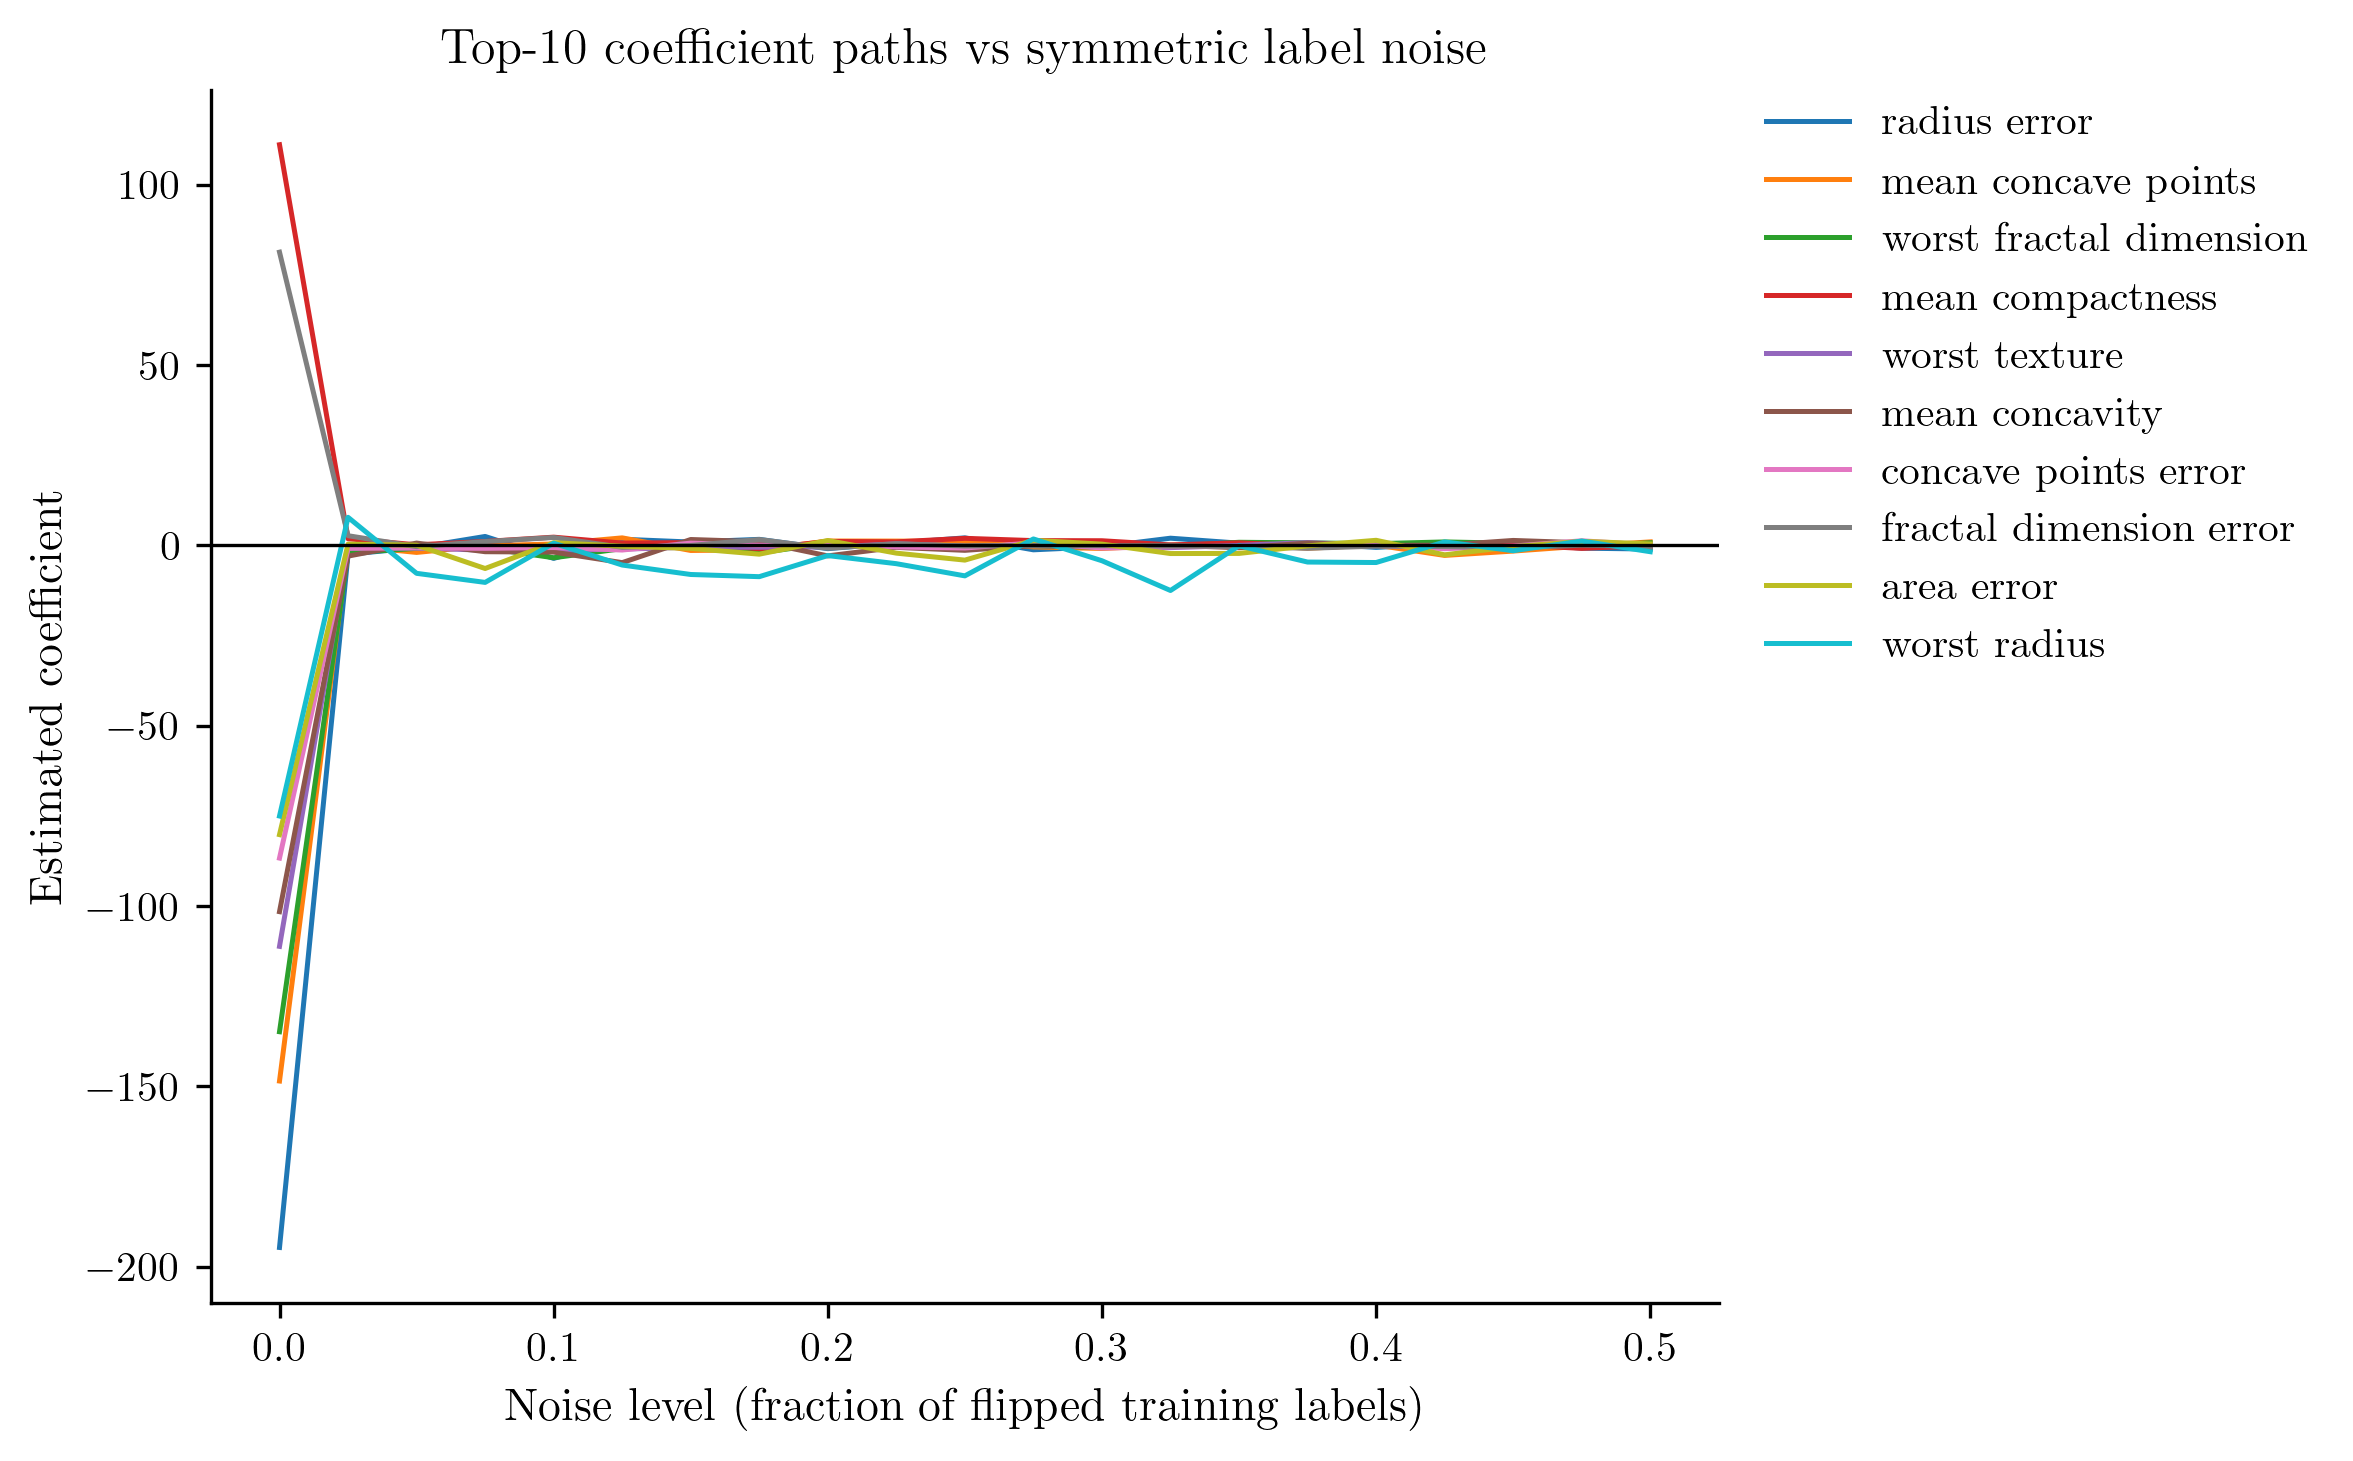

In [56]:
noise_grid = np.linspace(0.0, 0.5, 21)  
seed_noise_base = 6114                   
C_unreg = 1e6

# ---- fit baseline (noise=0) ----
clf_template = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        l1_ratio=0,
        C=C_unreg,
        solver="lbfgs",
        max_iter=5000
    ))
])

clf0 = clf_template
clf0.fit(X_train, y_train_true)
coef0 = clf0.named_steps["logreg"].coef_.ravel()

# ---- collect coefficient paths ----
p = X_train.shape[1]
coef_path = np.zeros((len(noise_grid), p), dtype=float)

for i, nl in enumerate(noise_grid):
    y_train_noisy, _ = add_symmetric_label_noise(
        y_train_true,
        noise_level=float(nl),
        seed=seed_noise_base + i
    )

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            l1_ratio=0,
            C=C_unreg,
            solver="lbfgs",
            max_iter=5000
        ))
    ])

    clf.fit(X_train, y_train_noisy)
    coef_path[i, :] = clf.named_steps["logreg"].coef_.ravel()

# ---- pick top-k coefficients by total movement from noise=0 to max noise ----
diff_total = coef_path[-1, :] - coef_path[0, :]
k = 10
top_idx = np.argsort(np.abs(diff_total))[-k:][::-1]

# ---- plot coefficient paths ----
plt.figure(figsize=(8, 5))
for j in top_idx:
    plt.plot(noise_grid, coef_path[:, j], label=feature_names[j])

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Noise level (fraction of flipped training labels)")
plt.ylabel("Estimated coefficient")
plt.title(f"Top-{k} coefficient paths vs symmetric label noise")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)
plt.tight_layout()

out_dir = os.path.join(project_root, "figures")
os.makedirs(out_dir, exist_ok=True)

save_latex_figure(
    os.path.join(out_dir, f"log_reg_coeffs.pdf")
)

plt.show()